In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/creditcard.csv')

In [2]:
# Shape
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")

# Data types and nulls
print("\n── dtypes & null check ──")
print(df.info())

# Target distribution — THE most important first check
print("\n── Class distribution ──")
counts = df['Class'].value_counts()
pct = df['Class'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': counts, 'Percentage': pct.round(4)}))


Rows: 284,807 | Columns: 31

── dtypes & null check ──
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20 

EDA

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/creditcard.csv')

# Missing values
print("── Missing values ──")
print(df.isnull().sum().sum(), "missing values found")

# Basic stats for Amount and Time
print("\n── Amount & Time stats ──")
print(df[['Amount', 'Time']].describe().round(2))

── Missing values ──
0 missing values found

── Amount & Time stats ──
          Amount       Time
count  284807.00  284807.00
mean       88.35   94813.86
std       250.12   47488.15
min         0.00       0.00
25%         5.60   54201.50
50%        22.00   84692.00
75%        77.16  139320.50
max     25691.16  172792.00


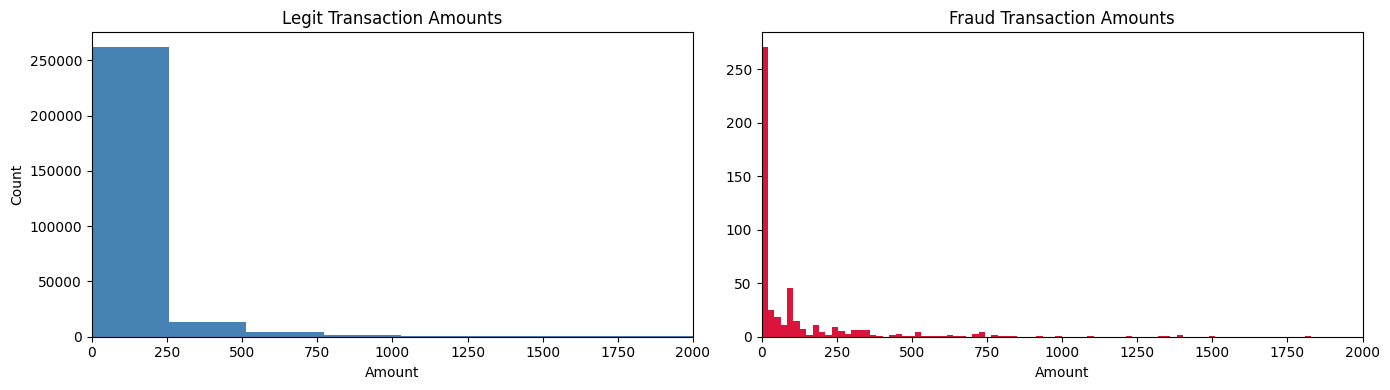

── Amount: Fraud vs Legit ──
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Legit
axes[0].hist(df[df['Class'] == 0]['Amount'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Legit Transaction Amounts')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 2000)

# Fraud
axes[1].hist(df[df['Class'] == 1]['Amount'], bins=100, color='crimson', edgecolor='none')
axes[1].set_title('Fraud Transaction Amounts')
axes[1].set_xlabel('Amount')
axes[1].set_xlim(0, 2000)

plt.tight_layout()
plt.savefig('eda_amount.png', dpi=150)
plt.show()

# Summary comparison
print("── Amount: Fraud vs Legit ──")
print(df.groupby('Class')['Amount'].describe().round(2))

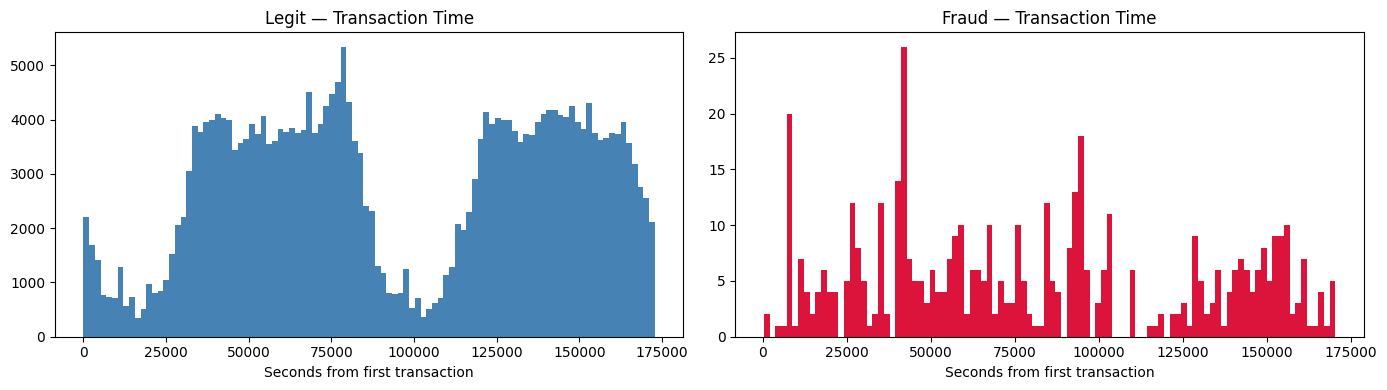

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[df['Class'] == 0]['Time'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Legit — Transaction Time')
axes[0].set_xlabel('Seconds from first transaction')

axes[1].hist(df[df['Class'] == 1]['Time'], bins=100, color='crimson', edgecolor='none')
axes[1].set_title('Fraud — Transaction Time')
axes[1].set_xlabel('Seconds from first transaction')

plt.tight_layout()
plt.savefig('eda_time.png', dpi=150)
plt.show()

In [7]:
# Mean value of each feature, split by class
feature_means = df.groupby('Class').mean().T

# Difference — bigger gap = more useful feature
feature_means['diff'] = abs(feature_means[1] - feature_means[0])
top_features = feature_means['diff'].sort_values(ascending=False).head(10)

print("── Top 10 features by fraud/legit mean difference ──")
print(top_features.round(4))

── Top 10 features by fraud/legit mean difference ──
Time      14091.3953
Amount       33.9203
V3            7.0455
V14           6.9838
V17           6.6774
V12           6.2702
V10           5.6867
V7            5.5784
V1            4.7802
V4            4.5499
Name: diff, dtype: float64


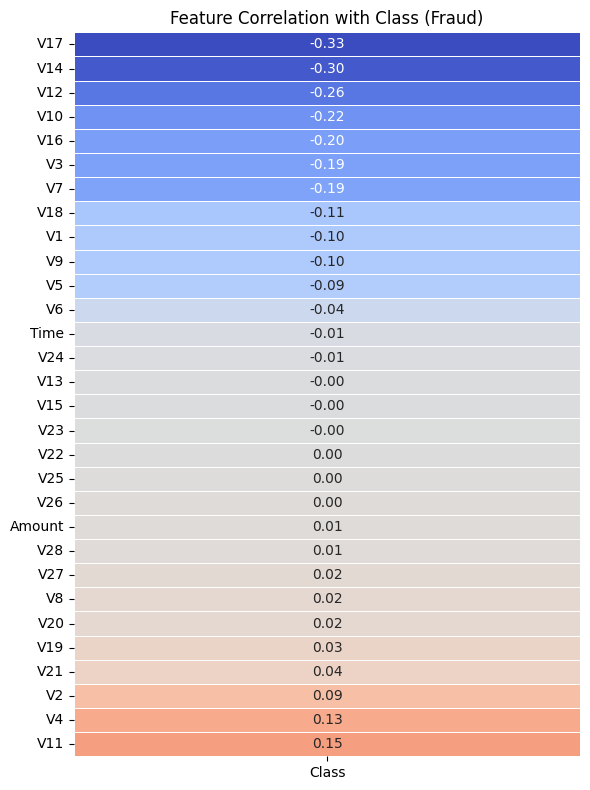

In [8]:
plt.figure(figsize=(6, 8))
corr = df.corr()[['Class']].drop('Class').sort_values('Class')

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, cbar=False)
plt.title('Feature Correlation with Class (Fraud)')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150)
plt.show()

Step 3 — Data Preprocessing

In [9]:
from sklearn.preprocessing import StandardScaler

df_processed = df.copy()

scaler = StandardScaler()

# Only scale Amount and Time — V1-V28 are already scaled from PCA
df_processed['Amount_Scaled'] = scaler.fit_transform(df_processed[['Amount']])
df_processed['Time_Scaled']   = scaler.fit_transform(df_processed[['Time']])

# Drop original unscaled columns
df_processed.drop(columns=['Amount', 'Time'], inplace=True)

print("Scaling done. Shape:", df_processed.shape)
print(df_processed[['Amount_Scaled', 'Time_Scaled']].describe().round(2))

Scaling done. Shape: (284807, 31)
       Amount_Scaled  Time_Scaled
count      284807.00    284807.00
mean           -0.00        -0.00
std             1.00         1.00
min            -0.35        -2.00
25%            -0.33        -0.86
50%            -0.27        -0.21
75%            -0.04         0.94
max           102.36         1.64


In [10]:
from sklearn.model_selection import train_test_split

X = df_processed.drop(columns=['Class'])
y = df_processed['Class']

# 80% train, 20% test
# stratify=y ensures both splits have the same fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # ← critical for imbalanced data
)

print(f"Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}")
print(f"\nTrain fraud count: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Test  fraud count: {y_test.sum()}  ({y_test.mean()*100:.2f}%)")

Train size: 227,845  |  Test size: 56,962

Train fraud count: 394 (0.17%)
Test  fraud count: 98  (0.17%)


In [11]:
from imblearn.over_sampling import SMOTE

# SMOTE creates synthetic fraud samples by interpolating between real ones
# Applied ONLY to training data — test set stays real and untouched
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE — Train shape: {X_train.shape}")
print(f"After SMOTE  — Train shape: {X_train_resampled.shape}")
print(f"\nClass distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Before SMOTE — Train shape: (227845, 30)
After SMOTE  — Train shape: (454902, 30)

Class distribution after SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


Step 4 — Baseline Model: Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# Train on SMOTE-resampled data
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)

print("Model trained.")

Model trained.


In [13]:
# Predict on REAL, untouched test set
y_pred_lr    = lr_model.predict(X_test)
y_prob_lr    = lr_model.predict_proba(X_test)[:, 1]  # fraud probability scores

print("── Classification Report ──")
print(classification_report(y_test, y_pred_lr, target_names=['Legit', 'Fraud']))

print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

── Classification Report ──
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

AUC-ROC Score: 0.9698


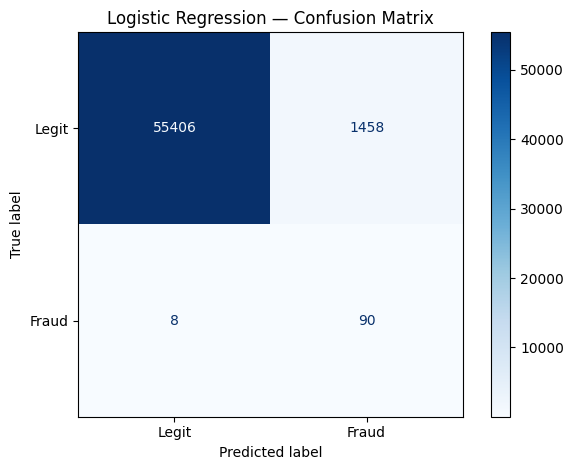


True Negatives  (correctly caught legit): 55,406
False Positives (legit flagged as fraud): 1,458
False Negatives (fraud missed entirely):  8
True Positives  (fraud correctly caught): 90

Fraud Recall: 91.8%  ← the number that matters most


In [14]:
cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Legit', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150)
plt.show()

# Break it down manually so you understand each number
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly caught legit): {tn:,}")
print(f"False Positives (legit flagged as fraud): {fp:,}")
print(f"False Negatives (fraud missed entirely):  {fn}")
print(f"True Positives  (fraud correctly caught): {tp}")
print(f"\nFraud Recall: {tp/(tp+fn)*100:.1f}%  ← the number that matters most")

Step 5 — Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,      # 100 trees
    max_depth=None,        # let trees grow fully
    random_state=42,
    n_jobs=-1              # use all CPU cores — speeds up training
)

rf_model.fit(X_train_resampled, y_train_resampled)
print("Random Forest trained.")

Random Forest trained.


In [16]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("── Classification Report ──")
print(classification_report(y_test, y_pred_rf, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

── Classification Report ──
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC Score: 0.9688


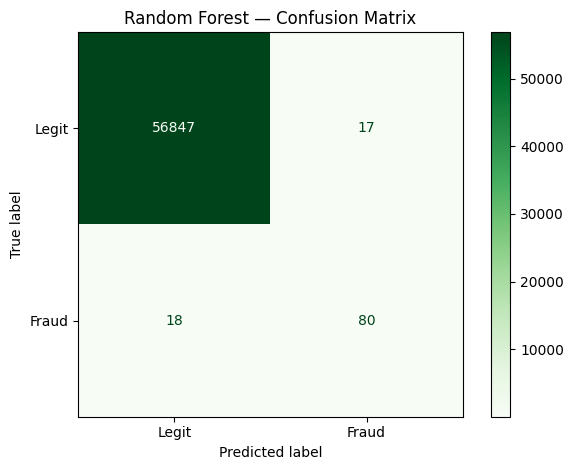


False Negatives (fraud missed): 18
False Positives (legit flagged): 17
Fraud Recall:    81.6%
Fraud Precision: 82.5%


In [17]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                               display_labels=['Legit', 'Fraud'])
disp.plot(cmap='Greens')
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print(f"\nFalse Negatives (fraud missed): {fn}")
print(f"False Positives (legit flagged): {fp}")
print(f"Fraud Recall:    {tp/(tp+fn)*100:.1f}%")
print(f"Fraud Precision: {tp/(tp+fp)*100:.1f}%")

In [18]:
from sklearn.metrics import recall_score, precision_score

results = {
    'Model':     ['Logistic Regression', 'Random Forest'],
    'Recall':    [recall_score(y_test, y_pred_lr),
                  recall_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr),
                  precision_score(y_test, y_pred_rf)],
    'AUC-ROC':   [roc_auc_score(y_test, y_prob_lr),
                  roc_auc_score(y_test, y_prob_rf)]
}

comparison_df = pd.DataFrame(results).set_index('Model')
print(comparison_df.round(4))

                     Recall  Precision  AUC-ROC
Model                                          
Logistic Regression  0.9184     0.0581   0.9698
Random Forest        0.8163     0.8247   0.9688


Step 6 — XGBoost

In [19]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,       # how much each tree corrects the previous
    max_depth=6,             # tree depth — controls complexity
    scale_pos_weight=1,      # 1 = balanced (we already used SMOTE)
    random_state=42,
    eval_metric='logloss',
    verbosity=0              # suppress training logs
)

xgb_model.fit(X_train_resampled, y_train_resampled)
print("XGBoost trained.")

XGBoost trained.


In [20]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("── Classification Report ──")
print(classification_report(y_test, y_pred_xgb, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

── Classification Report ──
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.35      0.87      0.49        98

    accuracy                           1.00     56962
   macro avg       0.67      0.93      0.75     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC Score: 0.9760


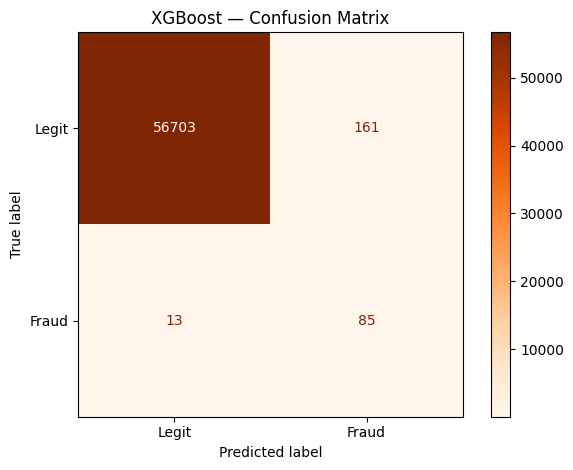


False Negatives (fraud missed): 13
False Positives (legit flagged): 161
Fraud Recall:    86.7%
Fraud Precision: 34.6%


In [21]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb,
                               display_labels=['Legit', 'Fraud'])
disp.plot(cmap='Oranges')
plt.title('XGBoost — Confusion Matrix')
plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm_xgb.ravel()
print(f"\nFalse Negatives (fraud missed): {fn}")
print(f"False Positives (legit flagged): {fp}")
print(f"Fraud Recall:    {tp/(tp+fn)*100:.1f}%")
print(f"Fraud Precision: {tp/(tp+fp)*100:.1f}%")

In [22]:
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Recall':     [recall_score(y_test, y_pred_lr),
                   recall_score(y_test, y_pred_rf),
                   recall_score(y_test, y_pred_xgb)],
    'Precision':  [precision_score(y_test, y_pred_lr),
                   precision_score(y_test, y_pred_rf),
                   precision_score(y_test, y_pred_xgb)],
    'AUC-ROC':    [roc_auc_score(y_test, y_prob_lr),
                   roc_auc_score(y_test, y_prob_rf),
                   roc_auc_score(y_test, y_prob_xgb)],
    'False Negatives': [
                   confusion_matrix(y_test, y_pred_lr).ravel()[2],
                   confusion_matrix(y_test, y_pred_rf).ravel()[2],
                   confusion_matrix(y_test, y_pred_xgb).ravel()[2]],
    'False Positives': [
                   confusion_matrix(y_test, y_pred_lr).ravel()[1],
                   confusion_matrix(y_test, y_pred_rf).ravel()[1],
                   confusion_matrix(y_test, y_pred_xgb).ravel()[1]]
}

comparison_df = pd.DataFrame(results).set_index('Model')
print(comparison_df.round(4))

                     Recall  Precision  AUC-ROC  False Negatives  \
Model                                                              
Logistic Regression  0.9184     0.0581   0.9698                8   
Random Forest        0.8163     0.8247   0.9688               18   
XGBoost              0.8673     0.3455   0.9760               13   

                     False Positives  
Model                                 
Logistic Regression             1458  
Random Forest                     17  
XGBoost                          161  


Step 7 — The ROC Curve & Precision-Recall Curve

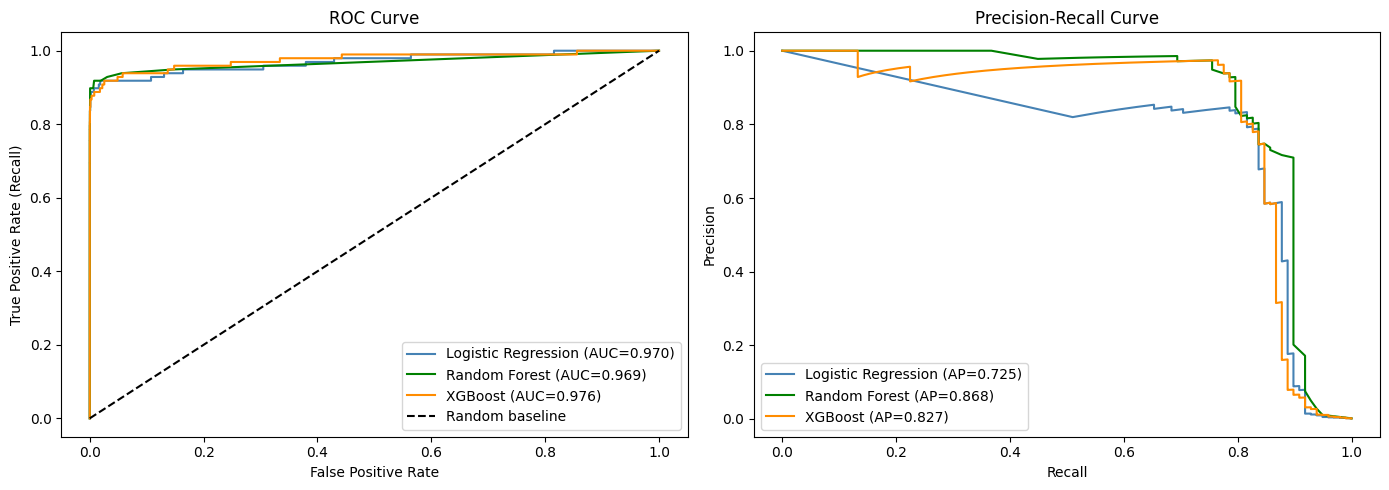

In [23]:
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = {
    'Logistic Regression': y_prob_lr,
    'Random Forest':       y_prob_rf,
    'XGBoost':             y_prob_xgb
}
colors = ['steelblue', 'green', 'darkorange']

# ── ROC Curve ──
for (name, probs), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0,1], [0,1], 'k--', label='Random baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve')
axes[0].legend()

# ── Precision-Recall Curve ──
for (name, probs), color in zip(models.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(recall, precision, color=color, label=f'{name} (AP={ap:.3f})')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150)
plt.show()

Default threshold (0.5):
  Recall=0.867  Precision=0.346

Optimal threshold (0.996) by F1:
  Recall=0.776  Precision=0.962
  F1=0.859


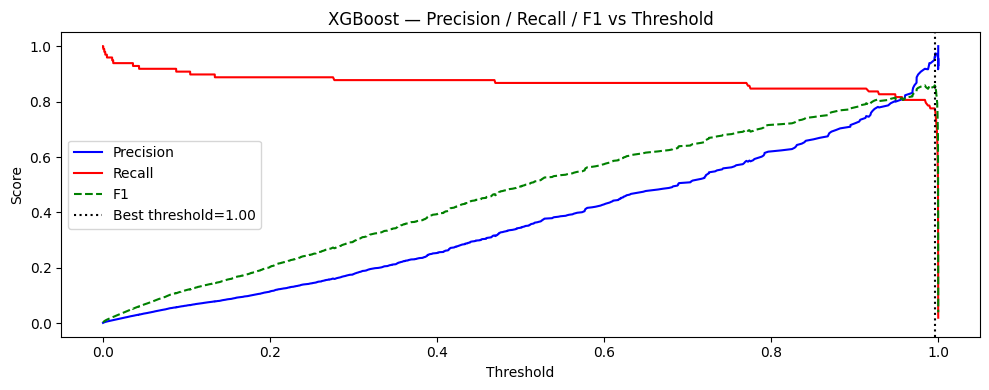

In [24]:
# For each threshold, calculate F1 score
# F1 balances precision and recall — good starting point
from sklearn.metrics import f1_score

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_xgb)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_threshold_idx = f1_scores.argmax()
best_threshold = thresholds[best_threshold_idx]

print(f"Default threshold (0.5):")
print(f"  Recall={recall_score(y_test, y_pred_xgb):.3f}  Precision={precision_score(y_test, y_pred_xgb):.3f}")

print(f"\nOptimal threshold ({best_threshold:.3f}) by F1:")
y_pred_xgb_tuned = (y_prob_xgb >= best_threshold).astype(int)
print(f"  Recall={recall_score(y_test, y_pred_xgb_tuned):.3f}  Precision={precision_score(y_test, y_pred_xgb_tuned):.3f}")
print(f"  F1={f1_score(y_test, y_pred_xgb_tuned):.3f}")

# Visualise the tradeoff
plt.figure(figsize=(10, 4))
plt.plot(thresholds, precisions[:-1], color='blue', label='Precision')
plt.plot(thresholds, recalls[:-1], color='red', label='Recall')
plt.plot(thresholds, f1_scores, color='green', linestyle='--', label='F1')
plt.axvline(x=best_threshold, color='black', linestyle=':', label=f'Best threshold={best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('XGBoost — Precision / Recall / F1 vs Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('threshold_curve.png', dpi=150)
plt.show()

In [25]:
from sklearn.metrics import f1_score, recall_score, precision_score

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_xgb)

# First, look at the distribution of XGBoost's probability scores
print("── XGBoost fraud probability score distribution ──")
print(pd.Series(y_prob_xgb).describe().round(4))
print(f"\nScores above 0.5:  {(y_prob_xgb > 0.5).sum()}")
print(f"Scores above 0.8:  {(y_prob_xgb > 0.8).sum()}")
print(f"Scores above 0.9:  {(y_prob_xgb > 0.9).sum()}")

# Only search thresholds in a meaningful range
mask = (thresholds >= 0.1) & (thresholds <= 0.95)
filtered_thresholds  = thresholds[mask]
filtered_precisions  = precisions[:-1][mask]
filtered_recalls     = recalls[:-1][mask]
filtered_f1          = 2 * (filtered_precisions * filtered_recalls) / \
                           (filtered_precisions + filtered_recalls + 1e-8)

best_idx       = filtered_f1.argmax()
best_threshold = filtered_thresholds[best_idx]

print(f"\n── Threshold search results ──")
print(f"Best threshold: {best_threshold:.3f}")
print(f"At this threshold:")
y_pred_tuned = (y_prob_xgb >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_tuned).ravel()
print(f"  Recall:    {tp/(tp+fn)*100:.1f}%")
print(f"  Precision: {tp/(tp+fp)*100:.1f}%")
print(f"  F1:        {f1_score(y_test, y_pred_tuned):.3f}")
print(f"  False Negatives: {fn}")
print(f"  False Positives: {fp}")

# Also manually check a few candidate thresholds
print("\n── Manual threshold scan ──")
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    y_temp = (y_prob_xgb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_temp).ravel()
    f1 = f1_score(y_test, y_temp)
    print(f"t={t:.1f}  Recall={tp/(tp+fn)*100:.1f}%  "
          f"Precision={tp/(tp+fp)*100:.1f}%  F1={f1:.3f}  "
          f"FN={fn}  FP={fp}")

── XGBoost fraud probability score distribution ──
count    56962.0000
mean         0.0131
std          0.0644
min          0.0000
25%          0.0004
50%          0.0011
75%          0.0046
max          0.9999
dtype: float64

Scores above 0.5:  246
Scores above 0.8:  133
Scores above 0.9:  115

── Threshold search results ──
Best threshold: 0.948
At this threshold:
  Recall:    82.7%
  Precision: 80.2%
  F1:        0.814
  False Negatives: 17
  False Positives: 20

── Manual threshold scan ──
t=0.3  Recall=87.8%  Precision=17.8%  F1=0.296  FN=12  FP=398
t=0.4  Recall=87.8%  Precision=25.4%  F1=0.394  FN=12  FP=252
t=0.5  Recall=86.7%  Precision=34.6%  F1=0.494  FN=13  FP=161
t=0.6  Recall=86.7%  Precision=43.1%  F1=0.576  FN=13  FP=112
t=0.7  Recall=86.7%  Precision=50.9%  F1=0.642  FN=13  FP=82
t=0.8  Recall=84.7%  Precision=62.4%  F1=0.719  FN=15  FP=50


Step 8 — SHAP: Feature Importance & Explainability

c:\Users\kalya\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


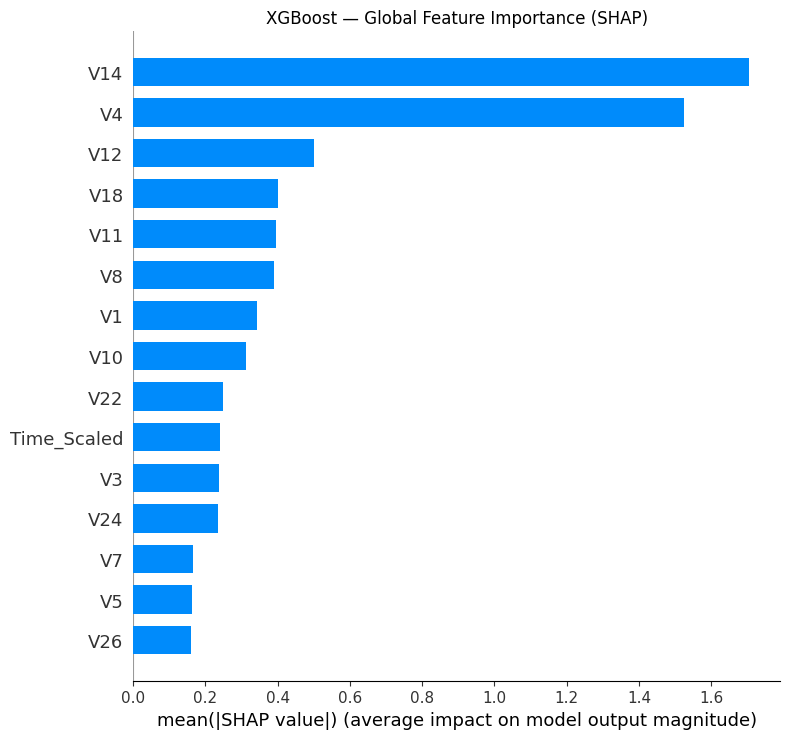

In [29]:
import shap

# Build SHAP explainer on XGBoost model
explainer  = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary plot — shows which features matter most overall
plt.figure()
shap.summary_plot(shap_values, X_test,
                  plot_type='bar',
                  max_display=15,
                  show=False)
plt.title('XGBoost — Global Feature Importance (SHAP)')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

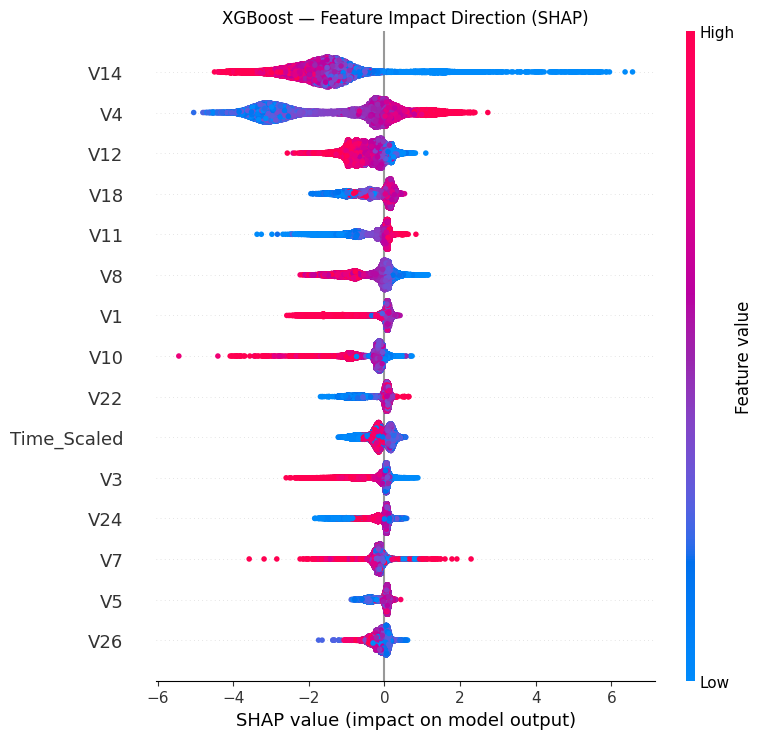

In [30]:
# Dot plot — shows both importance AND direction
# Red = high feature value, Blue = low feature value
# Right of center = pushes toward fraud, Left = pushes toward legit
plt.figure()
shap.summary_plot(shap_values, X_test,
                  max_display=15,
                  show=False)
plt.title('XGBoost — Feature Impact Direction (SHAP)')
plt.tight_layout()
plt.savefig('shap_direction.png', dpi=150, bbox_inches='tight')
plt.show()

Transaction fraud probability: 0.9998
Model decision at t=0.948: FRAUD


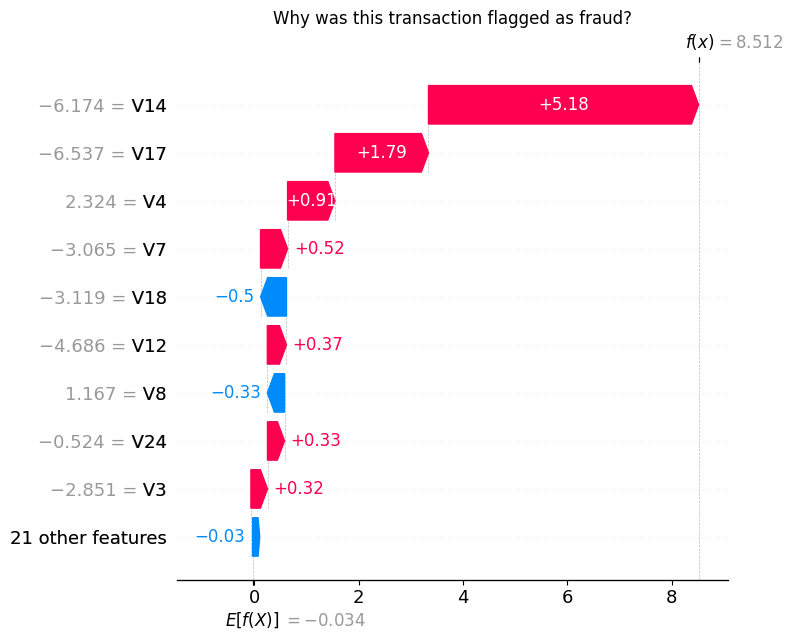

In [31]:
# Find an actual fraud case in the test set
fraud_indices = y_test[y_test == 1].index
first_fraud   = X_test.loc[fraud_indices[0]]

# Get its fraud probability
fraud_prob = xgb_model.predict_proba(first_fraud.values.reshape(1, -1))[0][1]
print(f"Transaction fraud probability: {fraud_prob:.4f}")
print(f"Model decision at t=0.948: {'FRAUD' if fraud_prob >= 0.948 else 'LEGIT'}")

# Waterfall plot — shows exactly why THIS transaction was flagged
shap_single = explainer.shap_values(first_fraud.values.reshape(1, -1))

shap.waterfall_plot(
    shap.Explanation(
        values      = shap_single[0],
        base_values = explainer.expected_value,
        data        = first_fraud.values,
        feature_names = X_test.columns.tolist()
    ),
    show=False
)
plt.title('Why was this transaction flagged as fraud?')
plt.tight_layout()
plt.savefig('shap_single_transaction.png', dpi=150, bbox_inches='tight')
plt.show()

Step 9 — SQL Pipeline: Simulating Real-Time Scoring

In [32]:
import sqlite3

# Save model predictions + probabilities for the full test set
scoring_df = X_test.copy()
scoring_df['true_label']       = y_test.values
scoring_df['fraud_probability'] = y_prob_xgb
scoring_df['predicted_label']  = (y_prob_xgb >= 0.948).astype(int)
scoring_df['flagged_for_review'] = scoring_df['predicted_label'].map(
                                        {1: 'YES', 0: 'NO'})

# Keep only what an analyst actually needs
output_df = scoring_df[['fraud_probability',
                         'predicted_label',
                         'flagged_for_review',
                         'true_label',
                         'Amount_Scaled',
                         'V14', 'V4', 'V12']].reset_index(drop=True)

output_df.index.name = 'transaction_id'
print(f"Scoring table shape: {output_df.shape}")
print(output_df.head(5).round(4))

Scoring table shape: (56962, 8)
                fraud_probability  predicted_label flagged_for_review  \
transaction_id                                                          
0                          0.0012                0                 NO   
1                          0.0002                0                 NO   
2                          0.0004                0                 NO   
3                          0.0001                0                 NO   
4                          0.0040                0                 NO   

                true_label  Amount_Scaled     V14      V4     V12  
transaction_id                                                     
0                        0        -0.2613  0.2664 -1.3284 -0.2300  
1                        0        -0.3059  0.9640 -1.0746 -1.5498  
2                        0        -0.0491 -2.4302  3.2637 -0.0641  
3                        0        -0.3493  0.1586  0.3860  0.7508  
4                        0        -0.3472 -3.538

In [33]:
# Create database and write scores
conn = sqlite3.connect('fraud_scores.db')
output_df.to_sql('transaction_scores', conn,
                  if_exists='replace', index=True)

print("Written to fraud_scores.db → table: transaction_scores")
conn.close()

Written to fraud_scores.db → table: transaction_scores


In [34]:
conn = sqlite3.connect('fraud_scores.db')

# Query 1: How many transactions flagged today?
q1 = pd.read_sql("""
    SELECT flagged_for_review,
           COUNT(*) as count,
           ROUND(AVG(fraud_probability), 4) as avg_fraud_prob
    FROM transaction_scores
    GROUP BY flagged_for_review
""", conn)
print("── Flagged vs Not Flagged ──")
print(q1)

# Query 2: High-confidence fraud (prob > 0.99) — immediate action needed
q2 = pd.read_sql("""
    SELECT transaction_id,
           ROUND(fraud_probability, 4) as fraud_prob,
           true_label
    FROM transaction_scores
    WHERE fraud_probability > 0.99
    ORDER BY fraud_probability DESC
    LIMIT 10
""", conn)
print("\n── Top 10 Highest Confidence Fraud Flags ──")
print(q2)

# Query 3: Missed fraud — false negatives for audit
q3 = pd.read_sql("""
    SELECT COUNT(*) as missed_fraud_count
    FROM transaction_scores
    WHERE true_label = 1
      AND predicted_label = 0
""", conn)
print("\n── Missed Fraud (False Negatives) ──")
print(q3)

conn.close()

── Flagged vs Not Flagged ──
  flagged_for_review  count  avg_fraud_prob
0                 NO  56861          0.0114
1                YES    101          0.9935

── Top 10 Highest Confidence Fraud Flags ──
   transaction_id  fraud_prob  true_label
0            1146      0.9999           1
1           31804      0.9999           1
2           54701      0.9998           1
3           43032      0.9998           1
4           46841      0.9998           1
5           50557      0.9998           1
6           54064      0.9998           1
7           54930      0.9998           1
8             840      0.9998           1
9           10623      0.9998           1

── Missed Fraud (False Negatives) ──
   missed_fraud_count
0                  17


In [36]:
import os

# Create the 'model' folder if it doesn't exist yet
os.makedirs('model', exist_ok=True)

In [37]:
import pickle
import joblib

# Save XGBoost model
joblib.dump(xgb_model, 'model/fraud_model.pkl')

# Save the scaler (needed to scale Amount and Time on new data)
joblib.dump(scaler, 'model/scaler.pkl')

# Save the feature column order — critical for prediction correctness
feature_columns = X_train_resampled.columns.tolist()
with open('model/feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

print("Saved:")
print(" model/fraud_model.pkl")
print(" model/scaler.pkl")
print(" model/feature_columns.pkl")
print(f"\nFeature count: {len(feature_columns)}")

Saved:
 model/fraud_model.pkl
 model/scaler.pkl
 model/feature_columns.pkl

Feature count: 30
